In [1]:
import os

GPU_NUM = 0
GPU_NUM = str(GPU_NUM)

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID" 
os.environ["CUDA_VISIBLE_DEVICES"] = GPU_NUM 

# torch를 CUDA_VISIBLE_DEVICES 뒤에 import 해야 제대로 설정됨.
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    print(f'CUDA Device Name: {torch.cuda.get_device_name(0)}, GPU NUM: {GPU_NUM}')
else: print(device)

torch.cuda.empty_cache() 

CUDA Device Name: NVIDIA RTX PRO 6000 Blackwell Server Edition, GPU NUM: 0


/workspace/.CondaEnvs/SamMed/lib/python3.12/site-packages/torch/cuda/__init__.py:235: UserWarning: 
NVIDIA RTX PRO 6000 Blackwell Server Edition with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_70 sm_75 sm_80 sm_86 sm_90.
If you want to use the NVIDIA RTX PRO 6000 Blackwell Server Edition GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


In [2]:
from dataclasses import dataclass

import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader

In [3]:
from utils.utils import *
from utils.config import Config

# allocate_dummy_gpu_memory(10)

In [4]:
cfg = Config(name='Dataset_Haze_Clutter', data='EchoNet-Dynamic')
print(cfg)

ECHO_DIR = Path(cfg.data_path) / 'data_raw' / cfg.data / 'frames'
SAVE_DIR = Path(cfg.data_path) / cfg.data

print(f'ECHO_DIR: {ECHO_DIR}')
print(f'SAVE_DIR: {SAVE_DIR}')

----------------------------------------------------------------------
                        Config Details (Auto)                         
----------------------------------------------------------------------

[ Base Settings ]
  name                   : Dataset_Haze_Clutter
  data                   : EchoNet-Dynamic
  mkdir                  : False
  dtype                  : float64
  device                 : cpu
  multi_gpu              : False

[ Paths ]
  base_path              : /ds/mkseo/SM-Dehazing
  data_path              : /ds/mkseo/SM-Dehazing/data
  res_path               : /ds/mkseo/SM-Dehazing/res/Dataset_Haze_Clutter
  fig_path               : /ds/mkseo/SM-Dehazing/res/Dataset_Haze_Clutter/fig
  loss_path              : /ds/mkseo/SM-Dehazing/res/Dataset_Haze_Clutter/loss
  model_path             : /ds/mkseo/SM-Dehazing/res/Dataset_Haze_Clutter/model
----------------------------------------------------------------------
ECHO_DIR: /ds/mkseo/SM-Dehazing/data/data_raw/Ech

In [5]:
echo_frames = globsort(ECHO_DIR)
print(f'Number of echo videos: {len(echo_frames)}')
print(*echo_frames[:5], sep='\n')

Number of echo videos: 30090
/ds/mkseo/SM-Dehazing/data/data_raw/EchoNet-Dynamic/frames/Patient_00001_F001.png
/ds/mkseo/SM-Dehazing/data/data_raw/EchoNet-Dynamic/frames/Patient_00001_F002.png
/ds/mkseo/SM-Dehazing/data/data_raw/EchoNet-Dynamic/frames/Patient_00001_F003.png
/ds/mkseo/SM-Dehazing/data/data_raw/EchoNet-Dynamic/frames/Patient_00002_F001.png
/ds/mkseo/SM-Dehazing/data/data_raw/EchoNet-Dynamic/frames/Patient_00002_F002.png


##### *Generative Noisy*

In [6]:
def keep_largest_component(mask, min_area=1000):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    if num_labels <= 1:
        return mask
    
    largest, largest_area = None, 0

    for label in range(1, num_labels):
        area = stats[label, cv2.CC_STAT_AREA]
        if area > largest_area:
            largest, largest_area = label, area

    comp = np.zeros_like(mask)
    if largest_area >= min_area:
        comp[labels == largest] = 255

    return comp

def ultrasound_sector_mask(
        img: np.ndarray,
        threshold_value: int = 5,
        erode_iter: int = 0,
        use_convex_hull: bool = True,
):
    if len(img.shape) == 3:
        RGB_chs = [3, 4]
        
        if img.shape[2] in RGB_chs: 
            code = cv2.COLOR_RGB2GRAY if img.shape[2] == 3 else cv2.COLOR_RGBA2GRAY
            gray = cv2.cvtColor(img, code)
            
        elif img.shape[0] in RGB_chs:
            code = cv2.COLOR_RGB2GRAY if img.shape[0] == 3 else cv2.COLOR_RGBA2GRAY
            img_hwc = img.transpose(1, 2, 0)
            gray = cv2.cvtColor(img_hwc, code)
        
    else:
        gray = img

    _, binary = cv2.threshold(gray, threshold_value, 255, cv2.THRESH_BINARY)

    largest_comp = keep_largest_component(binary)

    contours, _ = cv2.findContours(
        largest_comp, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    mask = np.zeros_like(largest_comp)
    if len(contours) > 0:
        contour = max(contours, key=cv2.contourArea)
        if use_convex_hull:
            hull = cv2.convexHull(contour)
            cv2.fillConvexPoly(mask, hull, 255)
        else:
            cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)

    if erode_iter > 0:
        erode_k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        mask = cv2.erode(mask, erode_k, iterations=erode_iter)

    return mask

Ultrasound Image Shape: (112, 112)


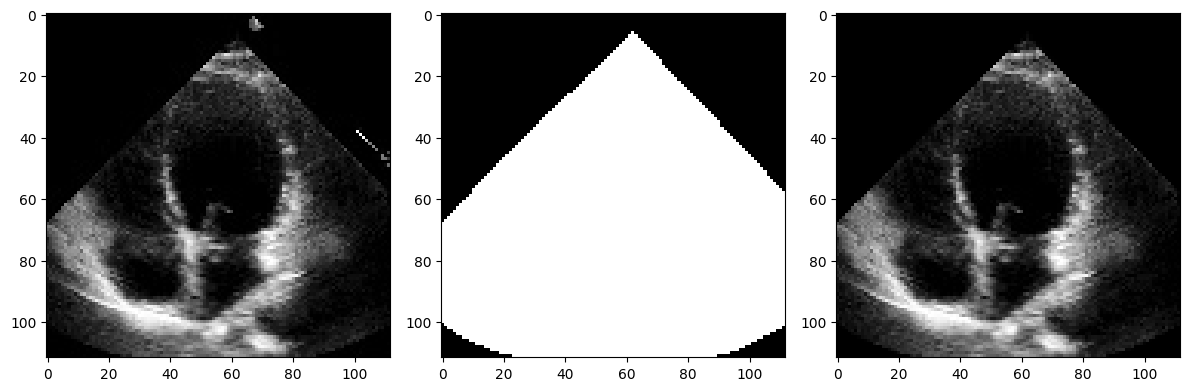

In [7]:
idx = np.random.randint(len(echo_frames))
us_img = cv2.imread(echo_frames[idx], cv2.IMREAD_GRAYSCALE)
# us_img = cv2.resize(us_img, (512, 512))
print(f'Ultrasound Image Shape: {us_img.shape}')

mask    = ultrasound_sector_mask(us_img, threshold_value=5, erode_iter=0, use_convex_hull=True)
imgs    = [us_img, mask, cv2.bitwise_and(us_img, us_img, mask=mask)]
titles  = ['Original', 'Sector Mask', 'Masked Image']

plt.figure(figsize=(12, 6))
for i, img in enumerate(imgs):
    plt.subplot(1, len(imgs), i+1)
    if img.ndim == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(img)

    # plt.grid(color='r')

plt.tight_layout()
plt.show()

In [8]:
def rayleigh_speckle(image: np.ndarray, speckle_rate: float = 0.2, eps: float = 1e-6):
    
    rng = np.random.default_rng()
    g1 = rng.standard_normal(size=image.shape)
    g2 = rng.standard_normal(size=image.shape)

    rayleigh = np.sqrt(g1**2 + g2**2 + eps)
    rayleigh = rayleigh / (rayleigh.mean(axis=(-2, -1), keepdims=True) + eps)

    speckle  = 1. + speckle_rate * (rayleigh - 1.)
    speckle  = np.clip(speckle, min=0.05)

    return speckle

def normalize01(x: np.ndarray, eps: float = 1e-6):
    x_min = x.min(axis=(-2, -1), keepdims=True)
    x_max = x.max(axis=(-2, -1), keepdims=True)

    return (x - x_min) / (x_max - x_min + eps)

def axial_grid_like(image: np.ndarray):
    h, w = image.shape[-2:]

    d       = np.linspace(0., 1., h, dtype=image.dtype)
    grid_2d = d[:, None] * np.ones((1, w), dtype=image.dtype)

    num_front_dims = image.ndim - 2
    for _ in range(num_front_dims):
        grid_2d = grid_2d[None, ...]

    return grid_2d

def gaussian_kernel2d(kernel_y: int, kernel_x: int, sigma_y: float, sigma_x: float):
    y = np.arange(kernel_y, dtype=np.float32) - (kernel_y - 1) // 2.
    x = np.arange(kernel_x, dtype=np.float32) - (kernel_x - 1) // 2.

    y_scaled, x_scaled = (y / sigma_y)**2, (x / sigma_x)**2
    kernel = np.exp(-0.5 * (y_scaled[:, None] + x_scaled[None, :]))

    kernel /= kernel.sum()

    return kernel

def anisotropic_psf_blur(image: np.ndarray, sigma_axial: float = 1., sigma_lateral: float = 3., kernel_scale: int = 6):
    ky = max(int(kernel_scale * sigma_axial) | 1, 3)
    kx = max(int(kernel_scale * sigma_lateral) | 1, 3)

    kernel = gaussian_kernel2d(ky, kx, sigma_y=sigma_axial, sigma_x=sigma_lateral)

    if image.ndim == 2:
        return cv2.filter2D(image, ddepth=-1, kernel=kernel, borderType=cv2.BORDER_REFLECT)
    
    elif image.ndim == 3:
        if image.shape[2] in [3, 4] or image.shape[2] == 1:
            return cv2.filter2D(image, ddepth=-1, kernel=kernel, borderType=cv2.BORDER_REFLECT)
        
        elif image.shape[0] in [3, 4] or image.shape[0] == 1:
            out = np.empty_like(image)
            for b in range(image.shape[0]):
                out[b] = cv2.filter2D(image[b], ddepth=-1, kernel=kernel, borderType=cv2.BORDER_REFLECT)
        else:
            for b in range(image.shape[0]):
                for c in range(image.shape[1]):
                    out[b, c] = cv2.filter2D(image[b, c], ddepth=-1, kernel=kernel, borderType=cv2.BORDER_REFLECT)
        return out
    else:
        raise ValueError(f'Unsupported image shape: {image.shape}')
    
def low_frequency_clutter(image: np.ndarray, strength: float = 1., sigma_axial: float = 18., sigma_lateral: float = 28.):
    rng     = np.random.default_rng()
    noise   = rng.standard_normal(size=image.shape, dtype=np.float32)

    clutter = anisotropic_psf_blur(noise, sigma_axial=sigma_axial, sigma_lateral=sigma_lateral)
    clutter = normalize01(clutter)

    return strength * clutter

def gaussian_haze(image: np.ndarray, haze_rate: float = 0.2, 
                  strength: float = 1., sigma_axial: float = 2., sigma_lateral: float = 5., type='haze'):
    
    rng = np.random.default_rng()
    type = type.lower()

    if type == 'haze':
        haze = low_frequency_clutter(
            np.zeros_like(image), 
            strength=strength)

        d    = axial_grid_like(image)
        haze = haze * (0.3 + 0.7 * d)

        haze = anisotropic_psf_blur(
            haze,
            sigma_axial=sigma_axial,
            sigma_lateral=sigma_lateral
        )

    elif type == 'gaussian':
        haze = rng.standard_normal(size=image.shape).astype(np.float32)
        haze = normalize01(haze) * strength

    else:
        raise ValueError("type must be either 'haze' or 'gaussian'")

    haze = normalize01(haze)

    return haze_rate * haze

def apply_ultrasound_noise(
    image: Any,
    speckle_rate: float = 0.2,
    haze_rate: float = 0.2,
    haze_type: str = 'haze',
    use_mask: bool = True,
):
    
    img = image.copy().astype(np.float32)
    if np.issubdtype(image.dtype, np.integer):
        img /= 255.0
    img = np.clip(img, 0., 1.)
    
    if use_mask:
        mask = ultrasound_sector_mask(image, threshold_value=5, erode_iter=0, use_convex_hull=True)
        mask = mask.astype(np.float32)
        if mask.max() > 1.0:
            mask /= 255.0
    else:
        mask = np.ones_like(image, dtype=np.float32)

    clean = img * mask

    # 1. Speckle Noise
    if speckle_rate > 0:
        speckle = rayleigh_speckle(clean, speckle_rate=speckle_rate)
        speckle = anisotropic_psf_blur(speckle, sigma_axial=0.5, sigma_lateral=1.5)
        speckle = speckle * mask + (1.0 - mask)
    else:
        speckle = np.ones_like(mask)

    # 2. Haze
    if haze_rate > 0:
        haze = gaussian_haze(clean, haze_rate=haze_rate, type=haze_type)
        haze = haze * mask
    else:
        haze = np.zeros_like(mask)
    
    noisy = (clean * speckle + haze) * mask
    # noisy = (clean * speckle + haze) * mask + clean * (1.0 - mask) # Keep the original outside the mask
    
    # noisy = np.clip(noisy, 0., 1.)
    
    return clean, noisy, mask, speckle, haze

def to_uint8(arr):
    if arr.dtype != np.uint8:
        arr = np.clip(arr * 255.0, 0, 255).round().astype(np.uint8)
    return arr

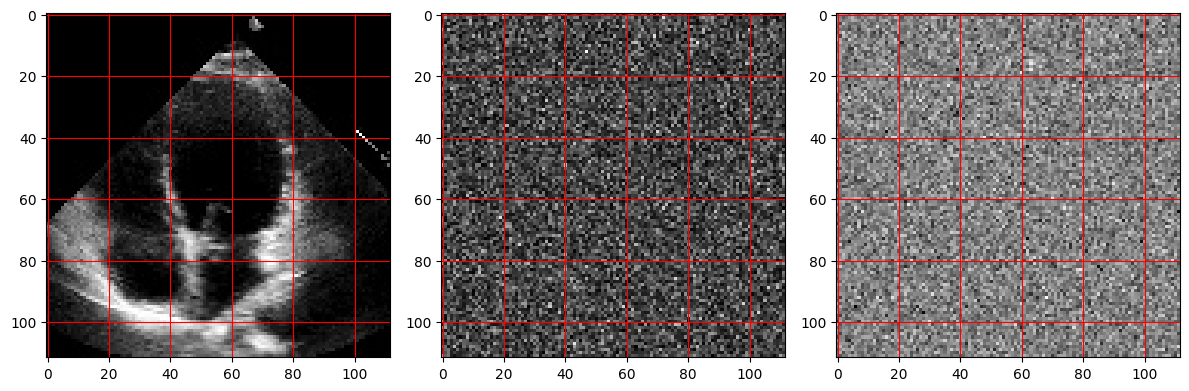

In [9]:
us_f32 = us_img.astype(np.float32)
speckle = rayleigh_speckle(us_f32, speckle_rate=0.4)
haze = gaussian_haze(us_f32, haze_rate=0.4, strength=1., sigma_axial=2., sigma_lateral=5., type='gaussian')

imgs = [us_img, speckle, haze]
titles = ['Original', 'Speckle Noise', 'Gaussian Haze']

plt.figure(figsize=(12, 6))
for i, img in enumerate(imgs):
    plt.subplot(1, len(imgs), i+1)
    if img.ndim == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(img)

    plt.grid(color='r')
plt.tight_layout()
plt.show()

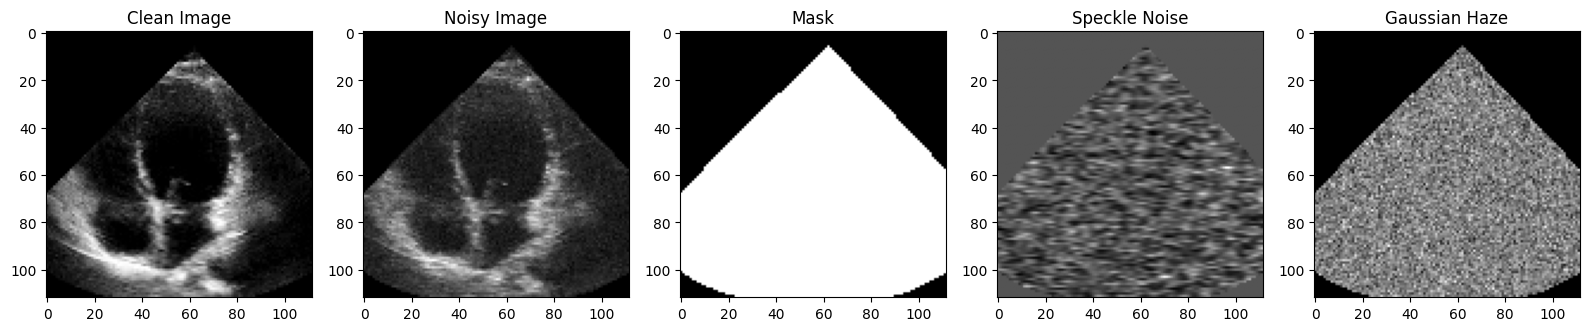

In [10]:
clean, noisy, mask, speckle, haze = apply_ultrasound_noise(
    us_img,
    speckle_rate=1.,
    haze_rate=0.3,
    haze_type='gaussian',
    use_mask=True
)

imgs = [
    clean, 
    noisy, 
    mask, 
    speckle, 
    haze
    ]
titles = [
    'Clean Image', 
    'Noisy Image', 
    'Mask', 
    'Speckle Noise', 
    'Gaussian Haze'
    ]

plt.figure(figsize=(16, 8))
for i, img in enumerate(imgs):
    plt.subplot(1, len(imgs), i+1)
    if img.ndim == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(img)
    
    plt.title(titles[i])
    # plt.axis('off')
    # plt.grid(color='r')
    
plt.tight_layout()
plt.show()

In [ ]:
FRAME_DIR = cfg.data_path / 'old' / cfg.data / 'clean'
echo_frames = listdir(FRAME_DIR)

Speckle_Noisy_DIR = SAVE_DIR / 'speckle' / 'noisy'
Speckle_Noise_DIR = SAVE_DIR / 'speckle' / 'noise'
Speckle_Clean_DIR = SAVE_DIR / 'speckle' / 'clean'
Speckle_Mask_DIR = SAVE_DIR / 'speckle' / 'mask'

mk_dir([Speckle_Noisy_DIR, Speckle_Noise_DIR, Speckle_Clean_DIR, Speckle_Mask_DIR])

rng = np.random.default_rng()
pbar = tqdm(echo_frames)
for frame in pbar:
    us_img = cv2.imread(str(FRAME_DIR / frame), 0)

    speckle_rate = rng.integers(100, 200, endpoint=True) / 100.0
    pbar.set_description(f"Processing {frame}")
    pbar.set_postfix(speckle_rate=f"{speckle_rate:.2f}")

    clean, noisy, mask, speckle, haze = apply_ultrasound_noise(
        us_img,
        speckle_rate=speckle_rate,
        haze_rate=0.,
        use_mask=True
    )

    clean_f32   = clean.astype(np.float32)
    noisy_f32   = noisy.astype(np.float32)
    speckle_f32 = speckle.astype(np.float32)
    mask_f32    = mask.astype(np.float32)

    # cv2.imwrite(str(Speckle_Clean_DIR / (Path(frame).stem + ".tiff")), clean_f32)
    # cv2.imwrite(str(Speckle_Noisy_DIR / (Path(frame).stem + ".tiff")), noisy_f32)
    # cv2.imwrite(str(Speckle_Noise_DIR / (Path(frame).stem + ".tiff")), speckle_f32)
    # cv2.imwrite(str(Speckle_Mask_DIR / (Path(frame).stem + ".tiff")), mask_f32)

In [ ]:
rng = np.random.default_rng()
idxs = rng.choice(len(echo_frames), size=5, replace=False)

imgs = [Image.open(FRAME_DIR / echo_frames[idx]) for idx in idxs]
titles = [f'Frame {idx}' for idx in idxs]
plt.figure(figsize=(16, 8))
for i, img in enumerate(imgs):
    plt.subplot(1, len(imgs), i+1)
    plt.imshow(img, cmap='gray')
    plt.imshow(mask, cmap='Reds', alpha=0.5)
    plt.title(titles[i])
    plt.axis('off')
    plt.grid(color='r')
plt.tight_layout()
plt.show()

##### *Filtering*

In [ ]:
def binarize_mask(mask):
    """
    mask: grayscale or binary image
    return: uint8 binary mask (0 or 255)
    """
    if mask.ndim == 3:
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)

    _, mask_bin = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    return mask_bin


def keep_largest_component(mask):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    if num_labels <= 1:
        return mask

    best_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])

    out = np.zeros_like(mask)
    out[labels == best_label] = 255
    return out


def preprocess_mask(mask, out_shape=None):
    mask = binarize_mask(mask)
    mask = keep_largest_component(mask)

    if out_shape is not None:
        mask = cv2.resize(mask, (out_shape[1], out_shape[0]), interpolation=cv2.INTER_NEAREST)

    return mask


def get_largest_contour(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return None
    return max(contours, key=cv2.contourArea)


def compute_iou(mask1, mask2):
    m1 = mask1 > 0
    m2 = mask2 > 0

    inter = np.logical_and(m1, m2).sum()
    union = np.logical_or(m1, m2).sum()

    if union == 0:
        return 0.0
    return inter / union


def compare_to_reference(ref_mask, test_mask):
    """
    return:
        iou_score: 높을수록 비슷
        shape_score: 낮을수록 비슷
    """
    ref_mask = preprocess_mask(ref_mask)
    test_mask = preprocess_mask(test_mask, out_shape=ref_mask.shape)

    ref_cnt = get_largest_contour(ref_mask)
    test_cnt = get_largest_contour(test_mask)

    if ref_cnt is None or test_cnt is None:
        return 0.0, float("inf")

    iou_score = compute_iou(ref_mask, test_mask)
    shape_score = cv2.matchShapes(ref_cnt, test_cnt, cv2.CONTOURS_MATCH_I1, 0.0)

    return iou_score, shape_score


def is_abnormal_mask(ref_mask, test_mask, iou_thresh=0.94, shape_thresh=0.03):
    """
    abnormal if:
      - IoU is too low
      - or shape difference is too high
    """
    iou_score, shape_score = compare_to_reference(ref_mask, test_mask)

    abnormal = (iou_score < iou_thresh) or (shape_score > shape_thresh)

    return abnormal, {
        "iou": iou_score,
        "shape_score": shape_score
    }

In [ ]:
mask_paths = globsort('/ds/mkseo/SM-Dehazing/data/EchoNet-Dynamic/speckle/mask')

ref_mask = cv2.imread(mask_paths[0], cv2.IMREAD_GRAYSCALE)

total_list = []
 
for path in tqdm(mask_paths):
    test_mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    abnormal, info = is_abnormal_mask(ref_mask, test_mask)
    
    total_list.append((path.stem, info))

100%|██████████| 30090/30090 [00:37<00:00, 803.64it/s]


In [ ]:
def plot_total_hist_with_threshold(
    total_score_list,
    key,
    threshold,
    abnormal_direction="low",
    bins=50
):
    """
    abnormal_direction:
        "low"  -> score가 threshold보다 낮으면 abnormal. 예: IoU
        "high" -> score가 threshold보다 높으면 abnormal. 예: shape_score
    """
    scores = [info[key] for _, info in total_score_list]
    scores = np.asarray(scores, dtype=np.float64)
    scores = scores[np.isfinite(scores)]

    plt.figure(figsize=(8, 5))

    plt.hist(
        scores,
        bins=bins,
        alpha=0.75,
        edgecolor="black"
    )

    plt.axvline(
        threshold,
        linestyle="--",
        linewidth=2,
        label=f"threshold = {threshold:.4f}"
    )

    if abnormal_direction == "low":
        abnormal_count = (scores < threshold).sum()
        normal_count = (scores >= threshold).sum()
        rule_text = f"abnormal: score < {threshold:.4f}"

    elif abnormal_direction == "high":
        abnormal_count = (scores > threshold).sum()
        normal_count = (scores <= threshold).sum()
        rule_text = f"abnormal: score > {threshold:.4f}"

    else:
        raise ValueError("abnormal_direction must be 'low' or 'high'")

    plt.xlabel(key.upper())
    plt.ylabel("Count")
    plt.title(
        f"Total {key} Distribution\n"
        f"{rule_text} | abnormal={abnormal_count}, remain={normal_count}, total={len(scores)}"
    )
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"[Total {key} Distribution]")
    print(f"Total count     : {len(scores)}")
    print(f"Threshold       : {threshold:.6f}")
    print(f"Abnormal count  : {abnormal_count}")
    print(f"Remaining count : {normal_count}")

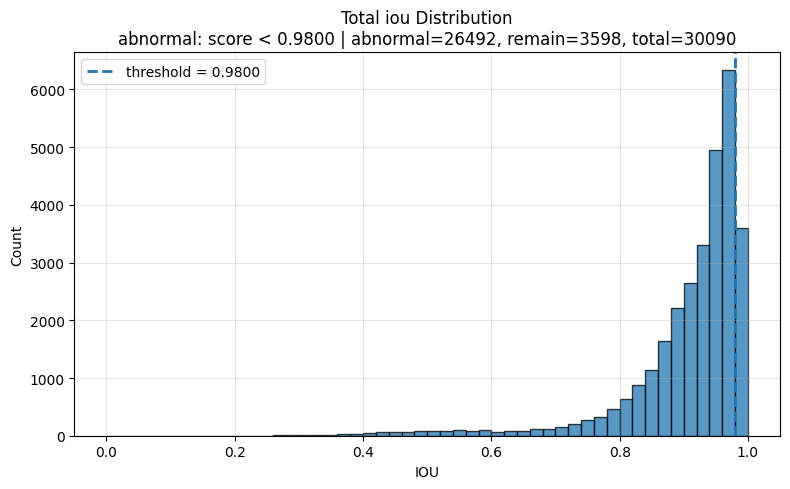

[Total iou Distribution]
Total count     : 30090
Threshold       : 0.980000
Abnormal count  : 26492
Remaining count : 3598


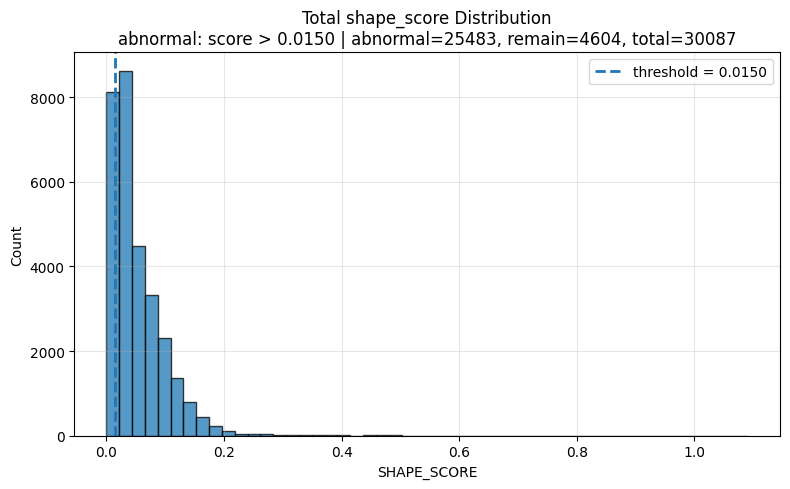

[Total shape_score Distribution]
Total count     : 30087
Threshold       : 0.015000
Abnormal count  : 25483
Remaining count : 4604


In [ ]:
plot_total_hist_with_threshold(
    total_list,
    key='iou',
    threshold=0.98,
    abnormal_direction="low",
    bins=50
)

plot_total_hist_with_threshold(
    total_list,
    key='shape_score',
    threshold=0.015,
    abnormal_direction="high",
    bins=50
)

In [ ]:
good_list, bad_list = [], []
for path in tqdm(mask_paths):
    test_mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    abnormal, info = is_abnormal_mask(ref_mask, test_mask, iou_thresh=0.98, shape_thresh=0.015)
    
    if abnormal:
        bad_list.append((path.stem, info))
    else:
        good_list.append((path.stem, info))

print(f'Good Count: {len(good_list)} / Bad Count: {len(bad_list)}')

100%|██████████| 30090/30090 [00:39<00:00, 756.03it/s]

Good Count: 3072 / Bad Count: 27018


In [ ]:
# SUB_DIR = SAVE_DIR / 'sub_speckle'
# SUB_CLEAN_DIR = SUB_DIR / 'clean'
# SUB_NOISY_DIR = SUB_DIR / 'noisy'
# SUB_NOISE_DIR = SUB_DIR / 'noise'
# SUB_MASK_DIR = SUB_DIR / 'mask'

# mk_dir([SUB_DIR, SUB_CLEAN_DIR, SUB_NOISY_DIR, SUB_NOISE_DIR, SUB_MASK_DIR])
# for pid, info in tqdm(good_list):
#     ori_clean_path = SAVE_DIR / 'speckle' / 'clean' / f'{pid}.tiff'
#     ori_noisy_path = SAVE_DIR / 'speckle' / 'noisy' / f'{pid}.tiff'
#     ori_noise_path = SAVE_DIR / 'speckle' / 'noise' / f'{pid}.tiff'
#     ori_mask_path = SAVE_DIR / 'speckle' / 'mask' / f'{pid}.png'

#     mv_clean_path = SUB_CLEAN_DIR / f'{pid}.tiff'
#     mv_noisy_path = SUB_NOISY_DIR / f'{pid}.tiff'
#     mv_noise_path = SUB_NOISE_DIR / f'{pid}.tiff'
#     mv_mask_path = SUB_MASK_DIR / f'{pid}.png'

#     shutil.copy(ori_clean_path, mv_clean_path)
#     shutil.copy(ori_noisy_path, mv_noisy_path)
#     shutil.copy(ori_noise_path, mv_noise_path)
#     shutil.copy(ori_mask_path, mv_mask_path)

100%|██████████| 3072/3072 [01:26<00:00, 35.63it/s]


##### *Comparative Visualization*

In [ ]:
us_img2 = cv2.imread(str(FRAME_DIR / echo_frames[9]), 0)\

speckle_rates   = [1.4 + 0.2 * i for i in range(10)]

speckle_imgs = []
for speckle_rate in speckle_rates:
    clean, noisy, _, _, _ = apply_ultrasound_noise(
        us_img2,
        speckle_rate=speckle_rate,
        haze_rate=0.,
        use_mask=True
    )
    speckle_imgs.append(noisy)

nrows = len(speckle_rates) // 5

plt.figure(figsize=(16, 8))
for i, img in enumerate(speckle_imgs):
    plt.subplot(nrows, len(speckle_rates)//nrows, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f'Speckle Rate: {speckle_rates[i]:.1f}')
    # plt.grid(color='r')

plt.tight_layout()
plt.show()

In [ ]:
haze_rates      = [0. + 0.1 * i for i in range(10)]

haze_imgs = []
for haze_rate in haze_rates:
    noisy, _, _, _ = apply_ultrasound_noise(
        us_img,
        speckle_rate=0.,
        haze_rate=haze_rate,
        use_mask=True
    )
    haze_imgs.append(noisy)

nrows = len(haze_rates) // 5

plt.figure(figsize=(16, 8))
for i, img in enumerate(haze_imgs):
    plt.subplot(nrows, len(haze_rates)//nrows, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f'Haze Rate: {haze_rates[i]:.1f}')
    # plt.grid(color='r')

plt.tight_layout()
plt.show()

In [ ]:
noisy_imgs = []
rates_list = []
for speckle_rate in speckle_rates:
    for haze_rate in haze_rates:
        noisy, _, _, _ = apply_ultrasound_noise(
            us_img,
            speckle_rate=speckle_rate,
            haze_rate=haze_rate,
            use_mask=True
        )
        noisy_imgs.append(noisy)
        rates_list.append((speckle_rate, haze_rate))

imgs_part1 = noisy_imgs[:len(noisy_imgs)//2]
nrows = len(imgs_part1) // 10
print(f'nrows: {nrows}, ncols: {len(imgs_part1)//nrows}')
plt.figure(figsize=(50, 25))
for i, img in enumerate(imgs_part1):
    plt.subplot(nrows, len(imgs_part1)//nrows, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f'Speckle: {rates_list[i][0]:.1f}, Haze: {rates_list[i][1]:.1f}', fontsize=24)
    plt.grid(color='r')

plt.tight_layout()
plt.show()

In [ ]:
imgs_part2 = noisy_imgs[len(noisy_imgs)//2:]
nrows = len(imgs_part2) // 10
print(f'nrows: {nrows}, ncols: {len(imgs_part2)//nrows}')

plt.figure(figsize=(50, 25))
for i, img in enumerate(imgs_part2):
    idx = i + len(imgs_part1)
    plt.subplot(nrows, len(imgs_part2)//nrows, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f'Speckle: {rates_list[idx][0]:.1f}, Haze: {rates_list[idx][1]:.1f}', fontsize=24)
    plt.grid(color='r')

plt.tight_layout()
plt.show()

#### *Final Generation*

In [11]:
PID_DIR = cfg.data_path / 'data_raw' / cfg.data / 'filtered_masks'
FRAME_DIR = cfg.data_path / 'data_raw' / cfg.data / 'frames'
pid_names = {p.stem for p in PID_DIR.iterdir() if p.is_file()}

echo_frames = [
    f for f in FRAME_DIR.iterdir()
    if f.is_file() and f.stem in pid_names
]

rng = np.random.default_rng(seed=42)
echo_frames = np.array(echo_frames)
rng.shuffle(echo_frames)

n_total = len(echo_frames)
n_train = int(n_total * 0.8)
n_valid = int(n_total * 0.1)

split_frames = {
    "train": echo_frames[:n_train],
    "valid": echo_frames[n_train:n_train + n_valid],
    "test":  echo_frames[n_train + n_valid:],
}

# ---- Save Dirs ----
BASE_DIR = SAVE_DIR / 'haze_deblur'

save_dirs = {}
for split in ["train", "valid", "test"]:
    save_dirs[split] = {
        "noisy": BASE_DIR / split / "noisy",
        "noise": BASE_DIR / split / "noise",
        "clean": BASE_DIR / split / "clean",
        # "mask": BASE_DIR / split / "mask",
    }

    mk_dir([
        save_dirs[split]["noisy"],
        save_dirs[split]["noise"],
        save_dirs[split]["clean"],
        # save_dirs[split]["mask"],
    ])

rng = np.random.default_rng()
for split, frames in split_frames.items():
    pbar = tqdm(frames, desc=f"Processing {split}")
    
    for frame in pbar:
        us_img = cv2.imread(str(frame), 0)

        haze_rate = rng.integers(30, 40, endpoint=True) / 100.0
        pbar.set_description(f"Processing {frame}")
        pbar.set_postfix(haze_rate=f"{haze_rate:.2f}")

        clean, noisy, mask, speckle, haze = apply_ultrasound_noise(
            us_img,
            speckle_rate=0,
            haze_rate=haze_rate,
            haze_type='gaussian',
            use_mask=True
        )

        stem = frame.stem

        cv2.imwrite(str(save_dirs[split]["clean"] / f"{stem}.tiff"), clean.astype(np.float32))
        cv2.imwrite(str(save_dirs[split]["noisy"] / f"{stem}.tiff"), noisy.astype(np.float32))
        cv2.imwrite(str(save_dirs[split]["noise"] / f"{stem}.tiff"), haze.astype(np.float32))
        # cv2.imwrite(str(save_dirs[split]["mask"] / f"{stem}.png"), mask)

Processing /ds/mkseo/SM-Dehazing/data/data_raw/EchoNet-Dynamic/frames/Patient_03534_F002.png: 100%|██████████| 2457/2457 [05:31<00:00,  7.41it/s, haze_rate=0.32]
Processing /ds/mkseo/SM-Dehazing/data/data_raw/EchoNet-Dynamic/frames/Patient_07040_F002.png: 100%|██████████| 307/307 [00:24<00:00, 12.43it/s, haze_rate=0.37]
Processing /ds/mkseo/SM-Dehazing/data/data_raw/EchoNet-Dynamic/frames/Patient_02509_F001.png: 100%|██████████| 308/308 [00:25<00:00, 12.26it/s, haze_rate=0.34]
